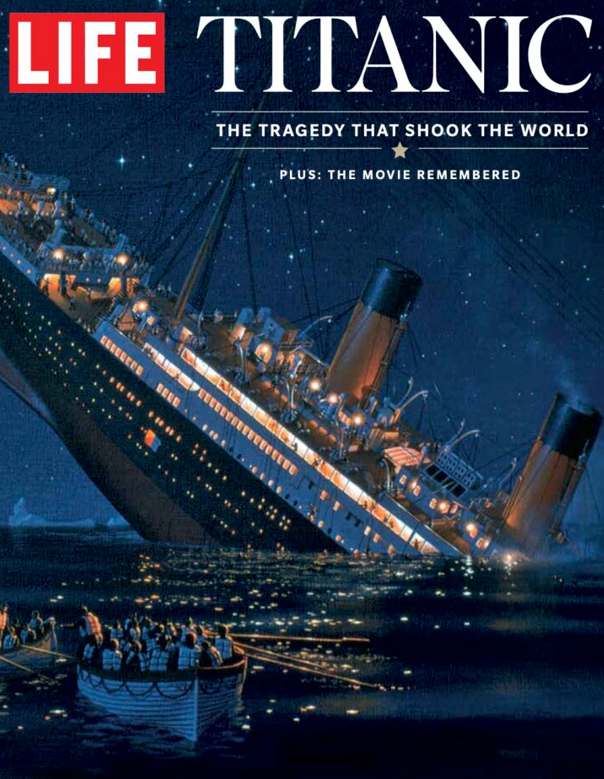

# STEP 1 — Data Loading & Understanding

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# SibSp - Number of siblings/spouses aboard, Why Important? Family size may affect : survival probability.
# Parch - Number of parents/children aboard.
# Embarked - Port where passenger boarded, Values: C → Cherbourg, Q → Queenstown, S → Southampton.

In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


**What are your initial observations from Titanic dataset?**

The dataset contains both numerical and categorical features, includes missing values in Age, Cabin, and Embarked columns, and the target variable is Survived. Some columns like PassengerId and Ticket may not contribute much to prediction and may require preprocessing.

# STEP 2 — Data Cleaning

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
# Filling Age with Median
df["Age"].fillna(df["Age"].median(),inplace=True)

/tmp/ipykernel_1168/1628645157.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)


In [11]:
# Filling Embarked with Mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

/tmp/ipykernel_1168/3831232365.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [12]:
# Dropping Cabin Column
df.drop("Cabin", axis=1, inplace=True)

# axis=1 → column
# axis=0 → row

In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**How do you handle missing values?**

Numerical columns are usually filled using mean or median depending on outliers, categorical columns are filled using mode, and columns with excessive missing values may be dropped.

# STEP 3 — Exploratory Data Analysis (EDA)

In [14]:
# How many passengers survived?
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


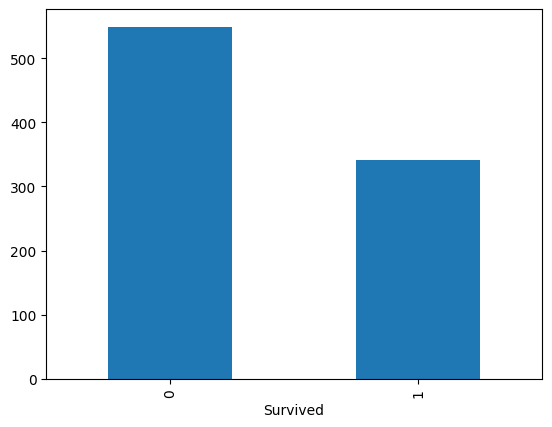

In [15]:
import matplotlib.pyplot as plt
df["Survived"].value_counts().plot(kind="bar")

plt.show()

**What initial insight did you get from target variable?**

The dataset shows that more passengers did not survive compared to those who survived, indicating a slightly imbalanced classification problem.

In [16]:
# Did females survive more than males?
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


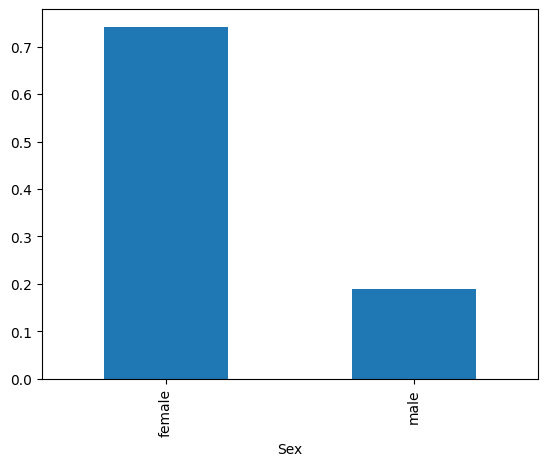

In [17]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar")

plt.show()

Female passengers had a significantly higher survival rate compared to males, indicating that gender was a strong factor affecting survival.

In [18]:
# Did Passenger Class Affect Survival?
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


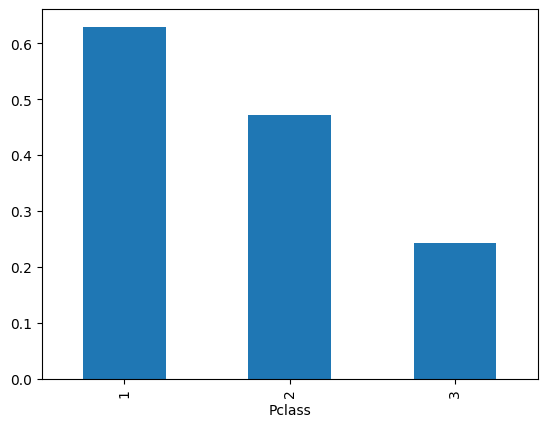

In [19]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")

plt.show()

First-class passengers had significantly higher survival rates compared to second and third-class passengers, indicating that socioeconomic status strongly influenced survival.

# STEP 4 — Outlier Detection & Skewness Analysis

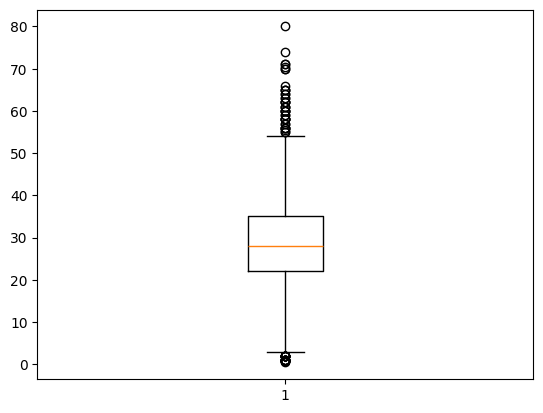

In [20]:
# Detecting Outliers
plt.boxplot(df["Age"])

plt.show()

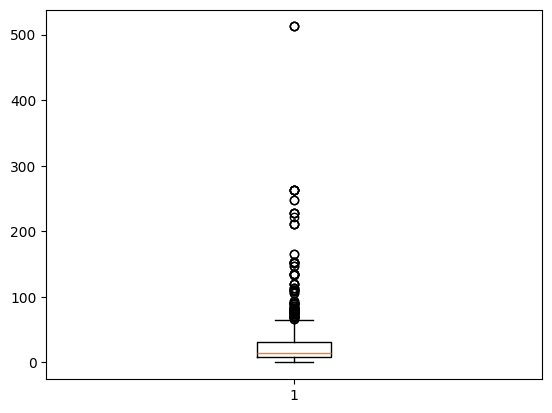

In [21]:
plt.boxplot(df["Fare"])

plt.show()

In [22]:
Q1 = df["Fare"].quantile(0.25)

Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: -26.724
Upper Limit: 65.6344


In [23]:
outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]

outliers.shape

(116, 11)

**Outliers should only be removed after understanding business context. Some outliers may represent important real-world information.**

In Titanic Dataset

High fare passengers are:

* real
* valid
* meaningful

They represent:

rich first-class passengers

So:

removing them blindly may lose important information

In [24]:
df["Fare"].skew()

np.float64(4.787316519674893)

In [25]:
df["Age"].skew()

np.float64(0.5102446555756495)

In [26]:
# Applying log transformation on fare
# Log transformation squeezes large values closer

df["Fare_log"] = np.log1p(df["Fare"])

Log transformation is used to reduce skewness and compress large values, making the data more normally distributed and improving model performance.

In [27]:
df["Fare_log"].skew()

np.float64(0.3949280095189306)

# STEP 5 — Correlation Analysis

In [28]:
# correlation matrix
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Fare_log
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.007425
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.329862
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,-0.661022
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.110964
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.318528
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.332186
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.787543
Fare_log,-0.007425,0.329862,-0.661022,0.110964,0.318528,0.332186,0.787543,1.000000


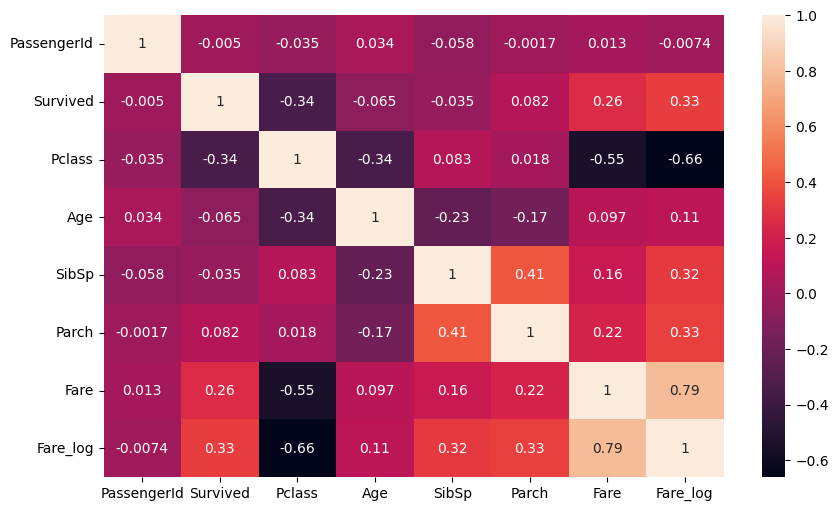

In [29]:
import seaborn as sns
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Pclass had a moderate negative correlation with survival, indicating lower-class passengers survived less. Fare showed positive correlation with survival, meaning higher-paying passengers had better survival chances. Fare and Fare_log showed high correlation because Fare_log was derived from Fare.

# STEP 6 — Feature Engineering & Encoding

Encoding means converting categorical/text data into numerical form so machine learning models can process it.
| Encoding         | Used When                     |
| ---------------- | ----------------------------- |
| Label Encoding   | Binary/ordered categories     |
| One-Hot Encoding | Multiple unordered categories |

In [30]:
df["Sex"] = df["Sex"].map({"male":0, "female":1})

In [31]:
df["Sex"].head()

,Sex
0,0
1,1
2,1
3,1
4,0


What is Dummy Variable Trap?

If all dummy columns are kept:

C	Q	S

1	0	0

Then:

one column becomes predictable from others

Example:

if C=0 and Q=0
then automatically S=1

This creates:

multicollinearity

In [32]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# drop_first=True is used to avoid the dummy variable trap and reduce multicollinearity between encoded features.

In [33]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Fare_log     891 non-null    float64
 11  Embarked_Q   891 non-null    bool   
 12  Embarked_S   891 non-null    bool   
dtypes: bool(2), float64(3), int64(6), object(2)
memory usage: 78.4+ KB


# STEP 7 — Feature Selection

In [34]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [35]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Fare_log,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2.110213,False,True
1,1,1,1,38.0,1,0,71.2833,4.280593,False,False
2,1,3,1,26.0,0,0,7.9250,2.188856,False,True
3,1,1,1,35.0,1,0,53.1000,3.990834,False,True
4,0,3,0,35.0,0,0,8.0500,2.202765,False,True


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Fare_log    891 non-null    float64
 8   Embarked_Q  891 non-null    bool   
 9   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(3), int64(5)
memory usage: 57.6 KB


# STEP 8 — Train-Test Split

In [37]:
x = df.drop("Survived", axis=1)
y = df["Survived"]

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# random_state ensures reproducibility by generating the same train-test split every time the code runs.

In [40]:
print(x_train.shape)

print(x_test.shape)

print(y_train.shape)

print(y_test.shape)

(712, 9)
(179, 9)
(712,)
(179,)


# STEP 9 — Feature Scaling

Feature scaling is the process of bringing numerical features to a similar range or scale.
| Method          | Use               |
| --------------- | ----------------- |
| Standardization | Most common       |
| Normalization   | Fixed range (0–1) |

Why Needed?

Suppose:

Feature	Range

Age	1–80

Fare	0–500

Problem:

Fare dominates because values are much larger

This affects:

* distance calculations
* optimization
* gradient descent

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [42]:
x_train_scaled = scaler.fit_transform(x_train)

# Why fit_transform()?
# fit() → learns mean/std
# transform() → applies scaling

In [43]:
x_test_scaled = scaler.transform(x_test)

# For test data:
# ONLY transform
# NOT fit_transform.

# Because:
# test data should remain unseen

Why scale AFTER train-test split?

VERY important concept.

If we scale BEFORE splitting:

test data information leaks into training

This causes:

data leakage

VERY dangerous ML mistake.

In [44]:
x_train_scaled[:5]

array([[-1.61413602, -0.7243102 ,  1.25364106, -0.47072241, -0.47934164,
        -0.07868358,  0.43740357, -0.30335547,  0.59248936],
       [-0.40055118, -0.7243102 , -0.47728355, -0.47072241, -0.47934164,
        -0.37714494, -0.32293549, -0.30335547,  0.59248936],
       [ 0.81303367, -0.7243102 ,  0.21508629, -0.47072241, -0.47934164,
        -0.47486697, -0.78220059, -0.30335547,  0.59248936],
       [ 0.81303367, -0.7243102 , -0.24649361,  0.37992316, -0.47934164,
        -0.47623026, -0.79032534, -0.30335547,  0.59248936],
       [ 0.81303367,  1.38062393, -1.78509326,  2.93185988,  2.04874166,
        -0.02524937,  0.5291163 , -0.30335547,  0.59248936]])

Feature scaling brings features to a similar range so that large-value features do not dominate the model. It improves performance for distance-based and gradient-based algorithms.

# STEP 10 — Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [46]:
model.fit(x_train_scaled, y_train)

LogisticRegression()

In [47]:
y_pred = model.predict(x_test_scaled)

# Now model predicts:

# survived
# not survived
# for unseen test data.

# THIS is actual ML prediction

In [48]:
y_pred[:10]
# model predictions for first 10 unseen passengers

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

# STEP 11 — Model Evaluation

In [49]:
# Accuracy
# It measures how many predictions were correct out of total predictions.

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.7988826815642458


In [50]:
# Confusion Matrix
# It is a table used to evaluate classification model performance by comparing actual and predicted values.

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

#[[TN FP]
 #[FN TP]]

[[89 16]
 [20 54]]


| Term | Meaning                              |
| ---- | ------------------------------------ |
| TP   | Correctly predicted survived         |
| TN   | Correctly predicted not survived     |
| FP   | Predicted survived but actually died |
| FN   | Predicted died but actually survived |


<function matplotlib.pyplot.show(close=None, block=None)>

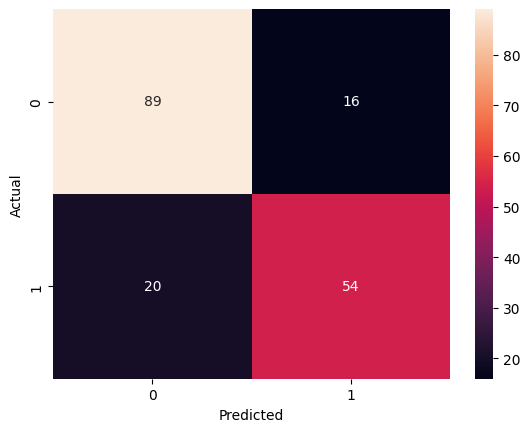

In [51]:
sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show

In [52]:
# Precision & Recall

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)   # "How correct are positive predictions?"

recall = recall_score(y_test, y_pred)   # "How many actual positives did we catch?"

f1 = f1_score(y_test, y_pred)

print("Precision:", precision)

print("Recall:", recall)

print("F1-score:", f1)

Precision: 0.7714285714285715
Recall: 0.7297297297297297
F1-score: 0.75


In [53]:
# ROC Metrics

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(x_test_scaled)[:,1]

In [54]:
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.8868725868725869


In [55]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

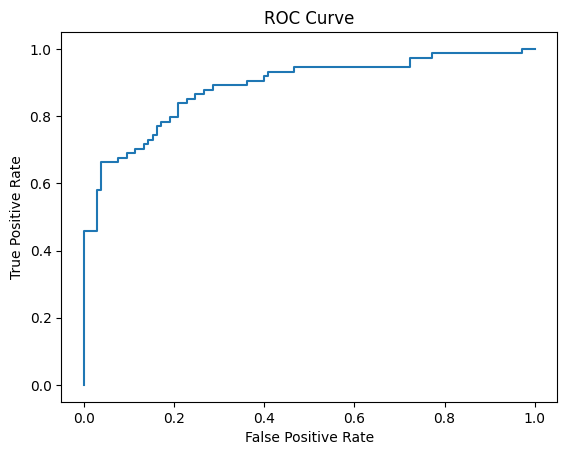

In [56]:
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

ROC-AUC measures the model’s ability to distinguish between classes across different thresholds and is especially useful for imbalanced datasets.

In [57]:
# Cross-validation
# Cross-validation provides a more reliable estimate of model performance
# by evaluating the model on multiple train-test splits instead of relying on a single split.

from sklearn.model_selection import cross_val_score

In [58]:
cv_scores = cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=5
)

In [59]:
print(cv_scores)
print(cv_scores.mean())

[0.82517483 0.79020979 0.77464789 0.73943662 0.79577465]
0.7850487540628386


# Decision Tree Model

In [60]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state = 42)

dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

In [61]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7932960893854749


In [62]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_dt))

[[85 20]
 [17 57]]


In [63]:
# GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10]},
             scoring='accuracy')

In [64]:
print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 3}


In [65]:
print(grid.best_score_)

0.8230079779375554


GridSearchCV was used to find the best hyperparameters for the Decision Tree model.
It tested multiple parameter combinations using 5-fold cross-validation.
The best parameters found were criterion='entropy' and max_depth=3.

In [66]:
# Tuned Decision Tree

best_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

best_dt.fit(x_train, y_train)

y_pred_best = best_dt.predict(x_test)

In [67]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred_best))

0.7988826815642458


A normal Decision Tree uses default parameters, while a tuned Decision Tree uses optimized hyperparameters selected through GridSearchCV. Tuning helps improve model stability and reduce overfitting.

I usually start with a default model as a baseline and then apply hyperparameter tuning using GridSearchCV. The final model is selected based on test performance and cross-validation results.

# Random Forest Model

Why Random Forest Was Invented?

Problem with a single Decision Tree: Can easily overfit

because one tree may learn:

* noise
* random patterns
* unnecessary details

🚀 Solution

Instead of: 1 Decision Tree

Use: 100+ Decision Trees and combine their predictions.

This is Random Forest.

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state = 42
)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [69]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test,y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8044692737430168


In [70]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test,y_pred_rf))

[[88 17]
 [18 56]]


In [71]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
1         Sex    0.271089
2         Age    0.228444
6    Fare_log    0.164816
5        Fare    0.152216
0      Pclass    0.079856
3       SibSp    0.042842
4       Parch    0.028085
8  Embarked_S    0.024048
7  Embarked_Q    0.008605


In [72]:
# VIF implementation
from statsmodels.stats.outliers_influence import variance_inflation_factor

x_vif = df.drop("Survived", axis=1)

In [73]:
x_vif = x_vif.astype(float)

In [74]:
vif_data = pd.DataFrame()

vif_data["Feature"] = x_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        x_vif.values,
        i
    )
    for i in range(len(x_vif.columns))
]

print(vif_data.sort_values(
    by="VIF",
    ascending=False
))

      Feature        VIF
6    Fare_log  16.939338
0      Pclass   6.785476
2         Age   6.420508
8  Embarked_S   4.997566
5        Fare   3.593751
1         Sex   1.761381
3       SibSp   1.677146
4       Parch   1.649153
7  Embarked_Q   1.627073


Fare_log was derived from Fare, so both variables contain overlapping information. This causes multicollinearity and results in a high VIF value. We shall remove this.

In [75]:
# Chi Square Test
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["Sex"],
    df["Survived"]
)

print(contingency_table)

Survived    0    1
Sex               
0         468  109
1          81  233


# Hypothesis Testing

Null Hypothesis (H₀):

Gender has no effect on survival.

Alternative Hypothesis (H₁):

Gender affects survival.

In [76]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square:", chi2)
print("P-value:", p_value)

Chi-square: 260.71702016732104
P-value: 1.1973570627755645e-58


Performing a Chi-Square Test between Gender and Survival. The p-value is extremely small (less than 0.05), So rejecting the null hypothesis and concluded that gender had a statistically significant impact on survival.

In [77]:
# Annova Test
from scipy.stats import f_oneway

fare_class1 = df[df["Pclass"] == 1]["Fare"]

fare_class2 = df[df["Pclass"] == 2]["Fare"]

fare_class3 = df[df["Pclass"] == 3]["Fare"]

ANOVA is used when we want to compare the means of a numerical variable across three or more categorical groups.

Example:

* Salary across departments
* Marks across schools
* Fare across passenger classes

In [78]:
f_stat, p_value = f_oneway(
    fare_class1,
    fare_class2,
    fare_class3
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 242.34415651744814
P-value: 1.0313763209141171e-84


Null Hypothesis (H₀):

Mean Fare of Class 1 = Mean Fare of Class 2 = Mean Fare of Class 3

No difference.

Alternative Hypothesis (H₁):

At least one class has a different mean fare.

In [79]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


# Time Series

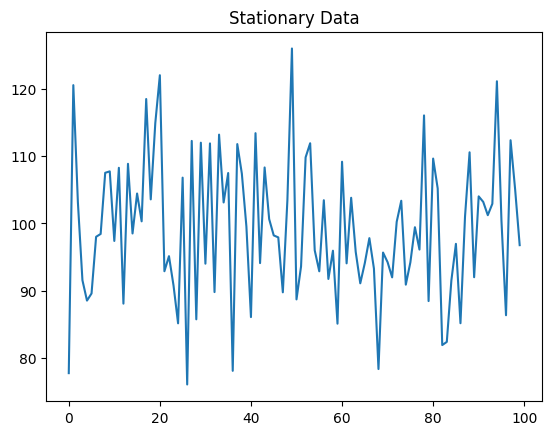

In [80]:
# Stationery Data
stationary = np.random.normal(
    loc=100,
    scale=10,
    size=100
)

plt.plot(stationary)
plt.title("Stationary Data")
plt.show()

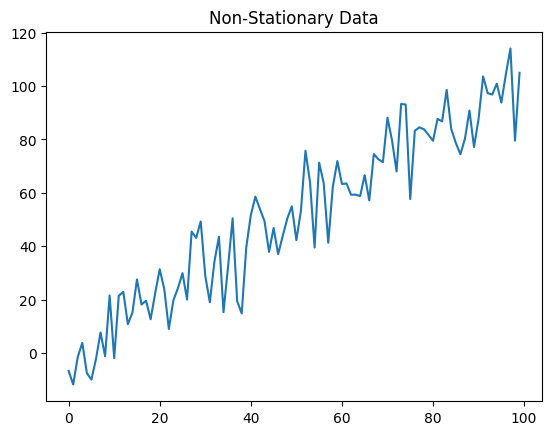

In [81]:
# Non-Stationery Data
trend = np.arange(100)

non_stationary = trend + np.random.normal(
    0,
    10,
    100
)

plt.plot(non_stationary)
plt.title("Non-Stationary Data")
plt.show()

The ADF Test is a statistical test used to determine whether a time series is stationary or non-stationary.

**ADF Test Hypotheses**

H₀ (Null Hypothesis):

Data is NON-STATIONARY

H₁ (Alternative Hypothesis):

Data is STATIONARY

In [82]:
from statsmodels.tsa.stattools import adfuller

# test stationery data
result = adfuller(stationary)

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -4.070522136465146
P-value: 0.0010830790690920752


In [83]:
# test non stationery data
result = adfuller(non_stationary)

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -0.939064714640373
P-value: 0.7748358726685068


**If Data Is Non-Stationary, How Will You Make It Stationary?**

Common techniques include differencing, seasonal differencing, log transformation, and detrending.

**Differencing** is the most commonly used method, where consecutive observations are subtracted to remove trends.

Differencing : Current Value - Previous Value

Seasonal Differencing : Removes seasonal patterns.

Log Transformation : Reduces variance and skewness.

Detrending : Removes trend component.

In [84]:
non_stationary_series = pd.Series(non_stationary)

differenced = non_stationary_series.diff()

In [85]:
# Removing null value
differenced = differenced.dropna()

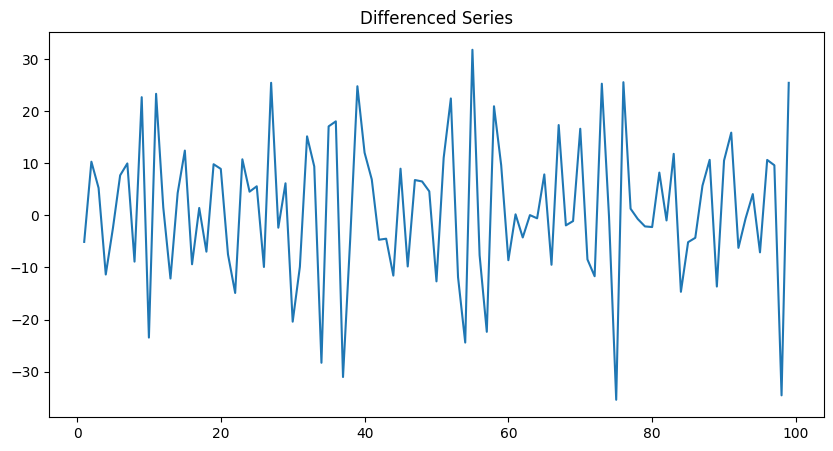

In [86]:
plt.figure(figsize=(10,5))

plt.plot(differenced)

plt.title("Differenced Series")

plt.show()

In [87]:
result = adfuller(differenced)

print("ADF Statistic:", result[0])

print("P-value:", result[1])

ADF Statistic: -6.291367836601941
P-value: 3.5925020184414345e-08


Before:

100
120
150
180
210

Trend exists.

Mean keeps increasing.

Non-stationary.

After Differencing:

20
30
30
30

Trend removed.

Mean becomes relatively stable.

Stationary.

# PCA
PCA reduces dimensionality by converting correlated features into fewer principal components while preserving most of the information. This reduces complexity, multicollinearity, and training time.

In [88]:
from sklearn.decomposition import PCA

pca = PCA()

In [89]:
pca.fit(x_train_scaled)

PCA()

In [90]:
print(pca.explained_variance_ratio_)

# Each number represents:
# How much information (variance) is captured by that Principal Component

[0.29376434 0.19106017 0.1723031  0.09822683 0.08247067 0.05980953
 0.04539432 0.04047921 0.01649182]


In [91]:
# cumulative_variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.29376434 0.48482451 0.65712761 0.75535444 0.83782511 0.89763465
 0.94302897 0.98350818 1.        ]


In [92]:
# pca dataset

from sklearn.decomposition import PCA

pca = PCA(n_components=8)

x_train_pca = pca.fit_transform(x_train_scaled)

x_test_pca = pca.transform(x_test_scaled)

print(x_train_pca.shape)
print(x_test_pca.shape)

(712, 8)
(179, 8)


**Difference Between PCA and VIF?**

Many interviewers ask this.

**VIF
Removes correlated features**

Example:

Remove: Fare_log

Keep: Fare

Original columns remain.

**PCA
Creates new features**

Example:

PC1
PC2
PC3

Original columns disappear.

**VIF :
Feature Removal**

**PCA :
Feature Transformation**

# KNN

In [93]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

In [94]:
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [95]:
y_pred_knn = knn.predict(x_test_scaled)

In [96]:
knn_accuracy = accuracy_score(y_test,y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.8268156424581006


In [97]:
print(confusion_matrix(y_test,y_pred_knn))

[[92 13]
 [18 56]]


Why did KNN perform well?

KNN works well when similar observations belong to similar classes. After feature scaling, the distance calculations became meaningful, allowing KNN to identify similar passengers effectively

#SVM

In [98]:
from sklearn.svm import SVC

svm = SVC(kernel = 'linear', random_state=42)

In [99]:
svm.fit(x_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [100]:
y_pred_svm = svm.predict(x_test_scaled)

In [101]:
svm_accuracy = accuracy_score(y_test,y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7821229050279329


In [102]:
print(confusion_matrix(y_test,y_pred_svm))

[[88 17]
 [22 52]]


#K-Means
(Unsupervised)

[0 2 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0]
Cluster
0    729
2    142
1     20
Name: count, dtype: int64


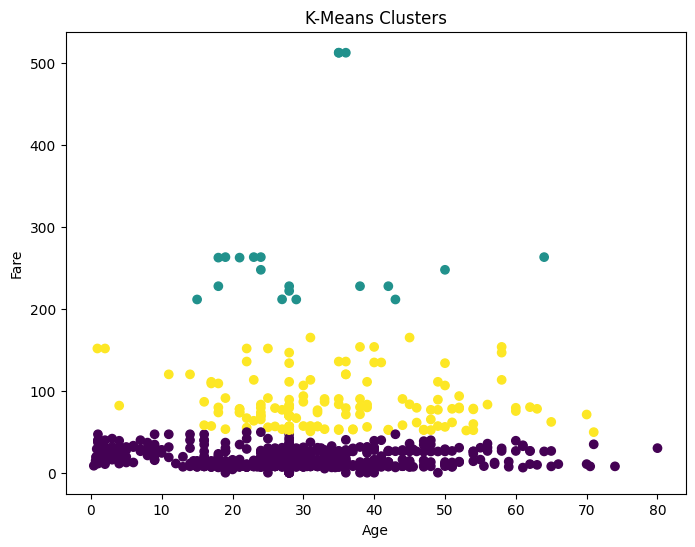

In [103]:
from sklearn.cluster import KMeans

X_cluster = df[['Age','Fare']]

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X_cluster)

clusters = kmeans.labels_

print(clusters[:20])

df['Cluster'] = clusters

print(
    df['Cluster'].value_counts()
)

plt.figure(figsize=(8,6))

plt.scatter(
    df['Age'],
    df['Fare'],
    c=df['Cluster']
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("K-Means Clusters")

plt.show()

K-Means grouped passengers into 3 clusters based on Age and Fare without using the Survived column. Similar passengers were grouped together according to their distance from cluster centroids.

In [104]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_cluster)

    wcss.append(
        kmeans.inertia_
    )

print(wcss)

[2348664.916180062, 1000032.6889194951, 545869.9514968555, 342251.65861997224, 285133.45356832544, 197007.76852406206, 140383.12392656543, 126281.49189722045, 112462.69275024501, 92537.968310444]


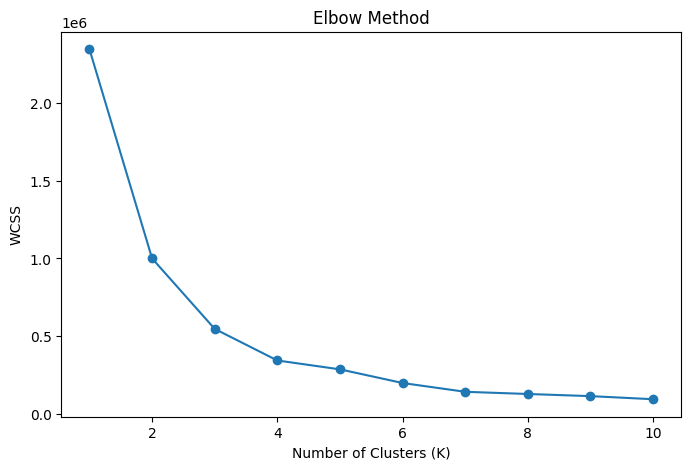

In [105]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

I use the Elbow Method. I calculate WCSS for different values of K and plot them. The point where the decrease in WCSS starts slowing significantly is called the elbow point and is selected as the optimal number of clusters.

#SVD

In [106]:
from numpy.linalg import svd

x_matrix = x_train_scaled

U, S, VT = svd(x_matrix)

print("U Shape:", U.shape)
print("S Shape:", S.shape)
print("VT Shape:", VT.shape)

U Shape: (712, 712)
S Shape: (9,)
VT Shape: (9, 9)
